# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Dataset overview

I am using a California Housing Dataset which derives from the 1990 census. Each row represents a census block group, which is the smallest geographic unit that the Census beureau publishes sample data.

### Target feature

My target feature is the median house value in the census block groups. The median house value in the data is capped at $500,000, which will be noted later.

### Input features

* Median income - The median income for the houses in the block.
* Average rooms - The median age of the houses in the block.
* House age - The average number of rooms per household.
* Latitude - The latitude of the block group.
* Average occupancy - How many occupants who live in the household.

# Conclusions

### Which features are most related to house value?
* Median income easily the strongest link to house value. with a R-square of 0.473. This makes sense because high income areas attract demand from wealthier clients and drives prices up.
* Average occupancy shows an obvious negative relationship, even though the R-squares is basically nonexistant. With more people living in each household, house values tend to drop which reflects the reality of lower income and denser households.

### Which features seem least related?
* House age has the weakest linear correlation with an R-squared of 0.011. While older neighborhoods near the coast can be desirable, age alone doesn't meaningfully determine value across the whole state.
* Average rooms (0.023) and Average occupancy (0.001) are both moderate with useful context, but far overshadowed by income.

### Big Picture Conclusion
California home values are primarily driven by what/how many people live in a neighborhood, not by the physical characteristics or location of the houses themselves.

Median income greatly overshadows the other features. Average occupancy adds good secondary angle where high value blocks usually have fewer people per household and more populated blocks are often lower in value. Together these two features tell how wealth buys space and space is priced into the home.



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import fetch_california_housing

raw = fetch_california_housing(as_frame=True)
df_full = raw.frame

df = df_full[['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'AveOccup', 'MedHouseVal']].copy()
df.columns = ['median_income', 'house_age', 'avg_rooms', 'latitude', 'avg_occupancy', 'median_house_value']

df['median_house_value'] = df['median_house_value'] * 100_000

print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 6)


,median_income,house_age,avg_rooms,latitude,avg_occupancy,median_house_value
0,8.3252,41.0,6.984127,37.88,2.555556,452600.0
1,8.3014,21.0,6.238137,37.86,2.109842,358500.0
2,7.2574,52.0,8.288136,37.85,2.802260,352100.0
3,5.6431,52.0,5.817352,37.85,2.547945,341300.0
4,3.8462,52.0,6.281853,37.85,2.181467,342200.0


Mean:   $206,856
Median: $179,700
Std:    $115,396


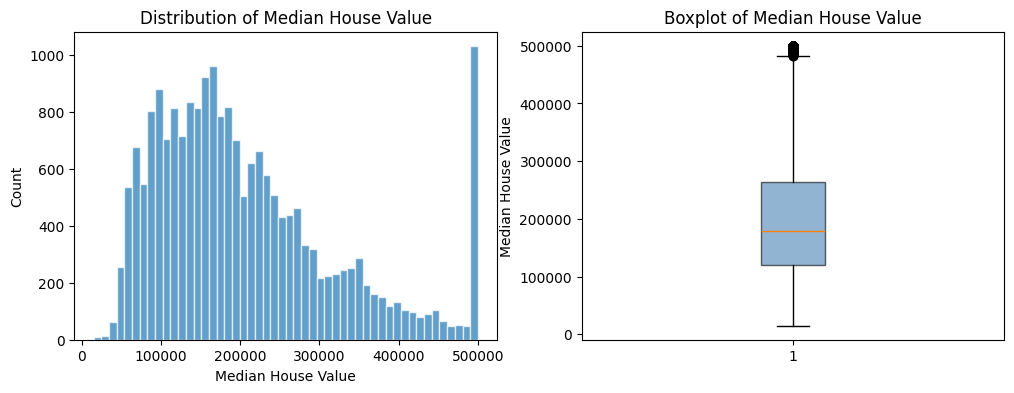

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['median_house_value'], bins=50, edgecolor='white', alpha=0.7)
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['median_house_value'], vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot of Median House Value')
axes[1].set_ylabel('Median House Value')

print(f"Mean:   ${df['median_house_value'].mean():,.0f}")
print(f"Median: ${df['median_house_value'].median():,.0f}")
print(f"Std:    ${df['median_house_value'].std():,.0f}")

plt.show()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:28:45   Log-Likelihood:            -2.6325e+05
No. Observations:               20640   AIC:                         5.265e+05
Df Residuals:                   20638   BIC:                         5.265e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.509e+04   1322.872     34.082      0.000    4.25e+04    4.77e+04
median_income  4.179e+04    306.806    136.223      0.000    4.12e+04    4.24e+04
==============================================================================
Omnibus:                     4245.795   Durbin-Watson:                   0.655
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9273.446
Skew:                           1.191   Prob(JB):                         0.00
Kurtosis:                       5.260   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

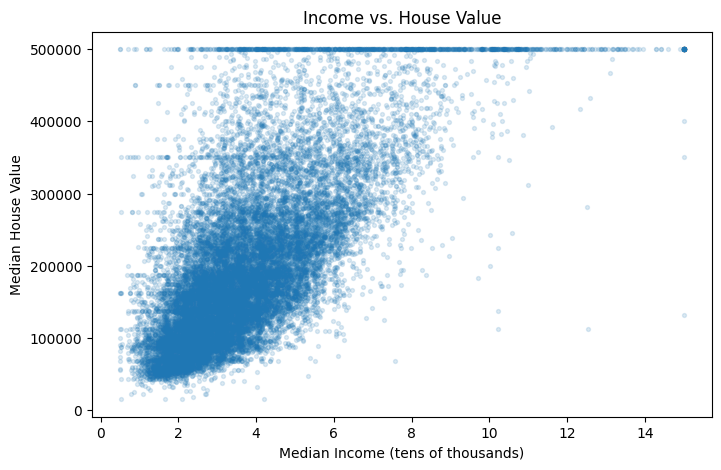

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['median_income'], df['median_house_value'], alpha=0.15, s=8)

ax.set_title('Income vs. House Value')
ax.set_xlabel('Median Income (tens of thousands)')
ax.set_ylabel('Median House Value')
plt.show

X_val = sm.add_constant(df['median_income'])
y_val = df['median_house_value']

model = sm.OLS(y_val, X_val).fit()

model.summary()

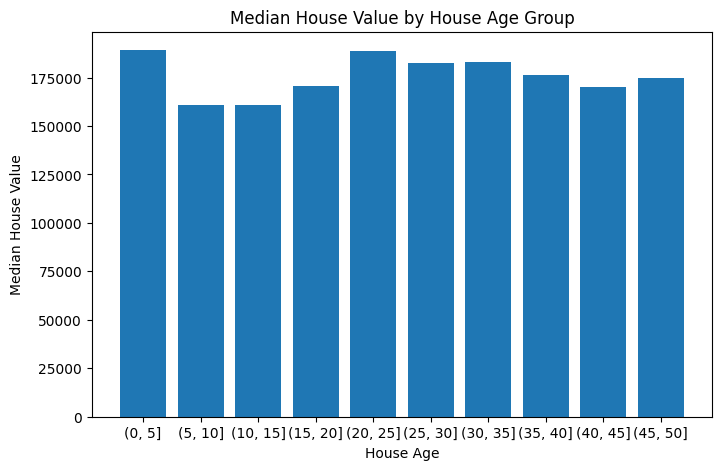

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     232.8
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           2.76e-52
Time:                        18:28:45   Log-Likelihood:            -2.6975e+05
No. Observations:               20640   AIC:                         5.395e+05
Df Residuals:                   20638   BIC:                         5.395e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.791e+05   1985.416     90.218      0.000    1.75e+05    1.83e+05
house_age    968.4496     63.467     15.259      0.000     844.050    1092.850
==============================================================================
Omnibus:                     2269.585   Durbin-Watson:                   0.325
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3093.615
Skew:                           0.938   Prob(JB):                         0.00
Kurtosis:                       3.281   Cond. No.                         77.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

df['age_bin'] = pd.cut(df['house_age'], bins=range(0, 55, 5))
age_group = df.groupby('age_bin', observed=True)['median_house_value'].median().reset_index()

ax.bar([str(b) for b in age_group['age_bin']], age_group['median_house_value'])
ax.set_title('Median House Value by House Age Group')
ax.set_xlabel('House Age')
ax.set_ylabel('Median House Value')
plt.show()

X_val = sm.add_constant(df['house_age'])
y_val = df['median_house_value']

model = sm.OLS(y_val, X_val).fit()

model.summary()

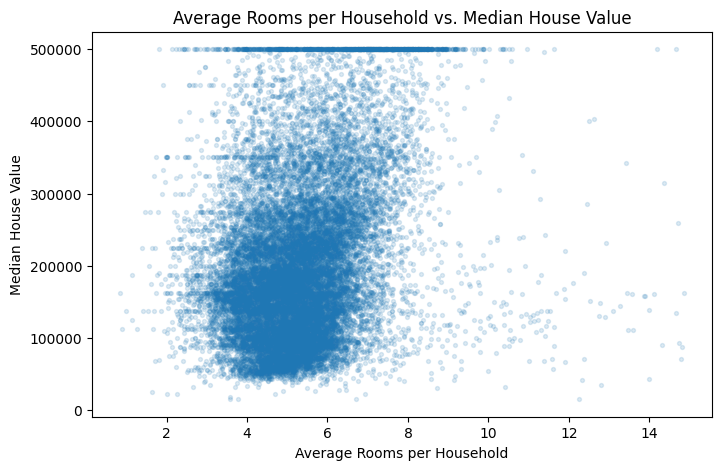

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     487.8
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          7.57e-107
Time:                        18:28:45   Log-Likelihood:            -2.6963e+05
No. Observations:               20640   AIC:                         5.393e+05
Df Residuals:                   20638   BIC:                         5.393e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.684e+05   1914.473     87.952      0.000    1.65e+05    1.72e+05
avg_rooms   7086.8793    320.888     22.085      0.000    6457.914    7715.845
==============================================================================
Omnibus:                     2121.129   Durbin-Watson:                   0.302
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2849.419
Skew:                           0.858   Prob(JB):                         0.00
Kurtosis:                       3.606   Cond. No.                         14.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# Cut outliers for better visuals
plot_df = df[df['avg_rooms'] < 15]

ax.scatter(plot_df['avg_rooms'], plot_df['median_house_value'], alpha=0.15, s=8)

ax.set_title('Average Rooms per Household vs. Median House Value')
ax.set_xlabel('Average Rooms per Household')
ax.set_ylabel('Median House Value')
plt.show()


X_val = sm.add_constant(df['avg_rooms'])
y_val = df['median_house_value']

model = sm.OLS(y_val, X_val).fit()

model.summary()

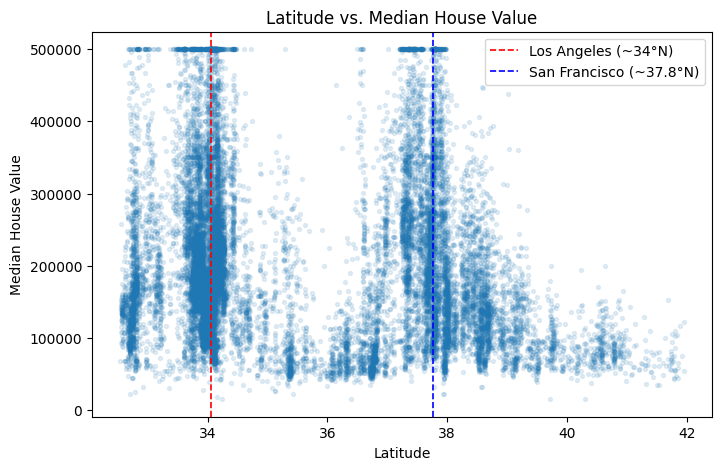

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     438.0
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           2.94e-96
Time:                        18:28:45   Log-Likelihood:            -2.6965e+05
No. Observations:               20640   AIC:                         5.393e+05
Df Residuals:                   20638   BIC:                         5.393e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.844e+05   1.33e+04     36.463      0.000    4.58e+05     5.1e+05
latitude   -7788.3121    372.138    -20.929      0.000   -8517.731   -7058.893
==============================================================================
Omnibus:                     2579.012   Durbin-Watson:                   0.315
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3651.620
Skew:                           1.013   Prob(JB):                         0.00
Kurtosis:                       3.380   Cond. No.                         597.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['latitude'], df['median_house_value'], alpha=0.12, s=8)

# Highlight LA (34°) and SF (~37.8°) latitude bands
ax.axvline(x=34.05, color='red', linestyle='--', linewidth=1.2, label='Los Angeles (~34°N)')
ax.axvline(x=37.77, color='blue', linestyle='--', linewidth=1.2, label='San Francisco (~37.8°N)')

ax.set_title('Latitude vs. Median House Value')
ax.set_xlabel('Latitude')
ax.set_ylabel('Median House Value')
ax.legend()
plt.show()

X_val = sm.add_constant(df['latitude'])
y_val = df['median_house_value']

model = sm.OLS(y_val, X_val).fit()

model.summary()

C:\Users\FlameFawn\AppData\Local\Temp\ipykernel_28684\1626201727.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


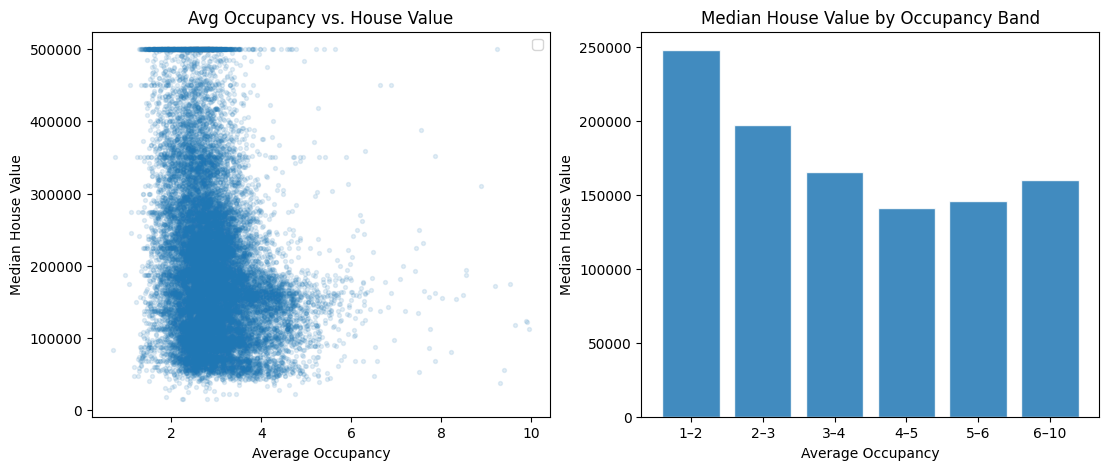

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.64
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           0.000648
Time:                        18:28:46   Log-Likelihood:            -2.6986e+05
No. Observations:               20640   AIC:                         5.397e+05
Df Residuals:                   20638   BIC:                         5.397e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.077e+05    837.375    247.996      0.000    2.06e+05    2.09e+05
avg_occupancy  -263.7378     77.318     -3.411      0.001    -415.288    -112.188
==============================================================================
Omnibus:                     2430.450   Durbin-Watson:                   0.310
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3379.600
Skew:                           0.978   Prob(JB):                         0.00
Kurtosis:                       3.327   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cap extreme outliers for a readable plot (occupancy >10 is likely data noise)
plot_df = df[df['avg_occupancy'] < 10]

# Scatter
axes[0].scatter(plot_df['avg_occupancy'], plot_df['median_house_value'], alpha=0.12, s=8,)
m, b = np.polyfit(plot_df['avg_occupancy'], plot_df['median_house_value'], 1)
x_line = np.linspace(plot_df['avg_occupancy'].min(), plot_df['avg_occupancy'].max(), 100)
axes[0].set_title('Avg Occupancy vs. House Value')
axes[0].set_xlabel('Average Occupancy')
axes[0].set_ylabel('Median House Value')
axes[0].legend()

plot_df = plot_df.copy()
plot_df['occ_bin'] = pd.cut(plot_df['avg_occupancy'], bins=[1, 2, 3, 4, 5, 6, 10], labels=['1–2', '2–3', '3–4', '4–5', '5–6', '6–10'])
occ_group = plot_df.groupby('occ_bin', observed=True)['median_house_value'].median()
axes[1].bar(occ_group.index.astype(str), occ_group.values, edgecolor='white', alpha=0.85)
axes[1].set_title('Median House Value by Occupancy Band')
axes[1].set_xlabel('Average Occupancy')
axes[1].set_ylabel('Median House Value')
plt.show()

X_val = sm.add_constant(df['avg_occupancy'])
y_val = df['median_house_value']

model = sm.OLS(y_val, X_val).fit()

model.summary()

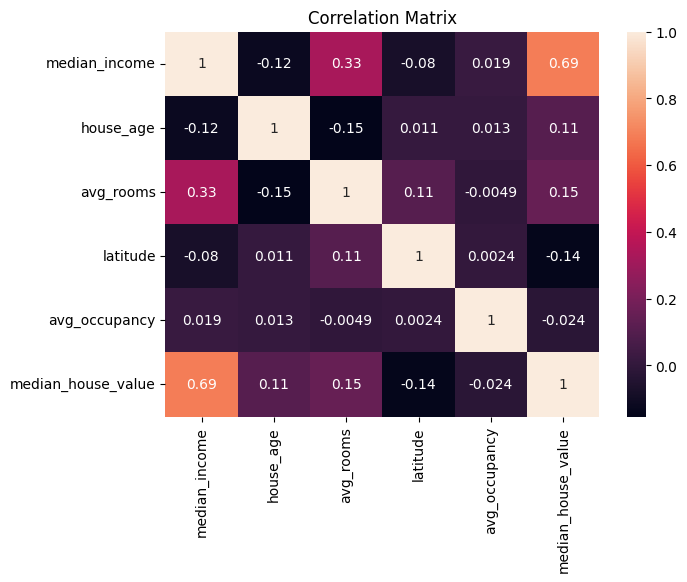

In [29]:
numeric_df = df[['median_income', 'house_age', 'avg_rooms', 'latitude', 'avg_occupancy', 'median_house_value']]

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True)
ax.set_title('Correlation Matrix')
plt.show()